# 04 · Exploratory analysis: what else explains revenue?

**Question:** beyond attribution, the funnel and customer segments, what does the data say about where revenue is won and lost?

Each section follows the same four steps: what the data shows, how much data supports it, what it does and doesn't mean, and what to do. Write-up: `docs/eda.md`.

1. How much the tracking fixes change the headline numbers
2. The funnel by device, with confidence intervals
3. Landing pages
4. Order values
5. Products and baskets
6. Repeat purchase by first-purchase month

In [1]:
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from marketing_analytics.eda import basket_pairs, rate_difference, sample_size_per_arm, wilson
from marketing_analytics.style import PAL, apply, finish

apply()
con = duckdb.connect("../warehouse.duckdb", read_only=True)
IMG = "../figures/eda"
sql = lambda q: con.sql(q).df()  # noqa: E731
pd.options.display.float_format = "{:,.4f}".format

## 1. How much do the tracking fixes change the answers?

Three versions of each number:
- **As GA4 reports it:** every purchase event counted, the store's own domain treated as a channel, all days included.
- **Corrected:** this project's rules (`docs/data_quality.md`).
- **Range:** the 837 orders without a transaction ID are the only ambiguous records. The low end treats all of them as duplicates (the usual "dedupe by ID" approach drops them); the high end keeps every one of those 906 events as a separate order.

In [2]:
raw = sql("""
    select count(*) as orders, sum(purchase_revenue_usd) as revenue,
           count(*) filter (where coalesce(transaction_id, '') in ('', '(not set)')) as no_id_events,
           sum(purchase_revenue_usd) filter (where coalesce(transaction_id, '') in ('', '(not set)')) as no_id_revenue
    from staging.stg_ga4__events where event_name = 'purchase'""").iloc[0]
fixed = sql("""
    select count(*) as orders, sum(purchase_revenue_usd) as revenue,
           count(*) filter (where has_transaction_id) as id_orders,
           sum(purchase_revenue_usd) filter (where has_transaction_id) as id_revenue
    from marts.fct_orders""").iloc[0]

orders_low, orders_high = fixed.id_orders, fixed.id_orders + raw.no_id_events
revenue_low, revenue_high = fixed.id_revenue, fixed.id_revenue + raw.no_id_revenue

shares = sql("""
    with naive as (
        select session_channel_group as channel, count(*) * 1.0 / sum(count(*)) over () as share
        from marts.fct_orders group by 1),
    corrected as (
        select channel, sum(credit) / sum(sum(credit)) over () as share
        from marts.fct_attribution_credits where model = 'last_click' group by 1)
    select channel, n.share as naive, c.share as corrected
    from naive n full join corrected c using (channel)""").set_index("channel").fillna(0)

funnel = sql("""
    select d.is_cart_tracking_ok as clean,
           count_if(reached_add_to_cart) * 1.0 / count_if(reached_view_item) as view_to_cart,
           count_if(reached_begin_checkout) * 1.0 / count_if(reached_add_to_cart) as cart_to_checkout
    from marts.fct_sessions s join marts.dim_date d on d.date = s.session_date
    group by grouping sets ((d.is_cart_tracking_ok), ())""")
all_days = funnel[funnel.clean.isna()].iloc[0]
clean_days = funnel[funnel.clean == True].iloc[0]  # noqa: E712

per_day = sql("""
    select d.month_label as month, d.is_revenue_tracking_ok as ok,
           sum(s.revenue_usd) as revenue, count(distinct d.date) as days
    from marts.fct_sessions s join marts.dim_date d on d.date = s.session_date
    group by 1, 2""")
def jan_vs_dec(rows):
    r = rows.groupby("month")[["revenue", "days"]].sum()
    return (r.loc["Jan 2021", "revenue"] / r.loc["Jan 2021", "days"]) / (r.loc["Dec 2020", "revenue"] / r.loc["Dec 2020", "days"]) - 1

sensitivity = pd.DataFrame([
    ("Orders", raw.orders, fixed.orders, orders_low, orders_high),
    ("Revenue ($)", raw.revenue, fixed.revenue, revenue_low, revenue_high),
    ("Average order value ($)", raw.revenue / raw.orders, fixed.revenue / fixed.orders,
     revenue_low / orders_low, revenue_high / orders_high),
    ("Organic Search share of last-click orders", shares.loc["Organic Search", "naive"],
     shares.loc["Organic Search", "corrected"], None, None),
    ("Share of orders credited to the store's own site", shares.loc["Internal Referral", "naive"],
     shares.loc["Internal Referral", "corrected"], None, None),
    ("Product view to cart rate", all_days.view_to_cart, clean_days.view_to_cart, None, None),
    ("Cart to checkout rate", all_days.cart_to_checkout, clean_days.cart_to_checkout, None, None),
    ("January revenue per day vs December", jan_vs_dec(per_day), jan_vs_dec(per_day[per_day.ok]), None, None),
], columns=["metric", "as_reported", "corrected", "range_low", "range_high"])
sensitivity["change"] = sensitivity.corrected / sensitivity.as_reported - 1
sensitivity

,metric,as_reported,corrected,range_low,range_high,change
0,Orders,"5,692.0000","5,288.0000","4,451.0000","5,357.0000",-0.0710
1,Revenue ($),"362,165.0000","338,347.0000","307,640.0000","339,457.0000",-0.0658
2,Average order value ($),63.6270,63.9839,69.1171,63.3670,0.0056
3,Organic Search share of last-click orders,0.3421,0.4087,NaN,NaN,0.1946
4,Share of orders credited to the store's own site,0.3005,0.0000,NaN,NaN,-1.0000
5,Product view to cart rate,0.1972,0.2570,NaN,NaN,0.3033
6,Cart to checkout rate,0.7312,0.5305,NaN,NaN,-0.2745
7,January revenue per day vs December,-0.6426,-0.5738,NaN,NaN,-0.1072


In [3]:
print(f"orders between {orders_low:,} and {orders_high:,} (corrected {fixed.orders:,}); "
      f"revenue ${revenue_low:,.0f} to ${revenue_high:,.0f} (corrected ${fixed.revenue:,.0f})")
moved = (shares.corrected - shares.naive).sort_values()
moved.round(3)

orders between 4,451.0 and 5,357.0 (corrected 5,288.0); revenue $307,640 to $339,457 (corrected $338,347)


channel
Internal Referral   -0.3000
Affiliates           0.0000
Email                0.0010
Paid Search          0.0030
Obfuscated           0.0150
Referral             0.0350
Direct               0.0430
Organic Search       0.0670
Unknown              0.1360
dtype: float64

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


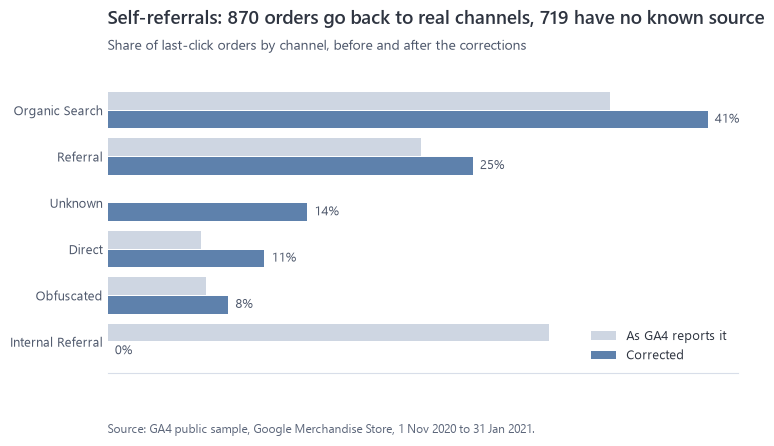

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.6))
plot = shares.drop(index=[c for c in shares.index if shares.loc[c].max() < 0.02]).sort_values("corrected")
y = np.arange(len(plot))
ax.barh(y + 0.2, plot.naive * 100, 0.38, color=PAL["context"], label="As GA4 reports it")
ax.barh(y - 0.2, plot.corrected * 100, 0.38, color=PAL["primary"], label="Corrected")
for yi, v in zip(y - 0.2, plot.corrected * 100):
    ax.text(v + 0.5, yi, f"{v:.0f}%", va="center", fontsize=9, color=PAL["ink_2"])
ax.set_yticks(y, plot.index); ax.set_xticks([]); ax.grid(False)
ax.legend(loc="lower right")
self_ref = round(shares.loc["Internal Referral", "naive"] * fixed.orders)
unknown = round(shares.loc["Unknown", "corrected"] * fixed.orders)
finish(fig, ax, f"Self-referrals: {self_ref - unknown:,} orders go back to real channels, {unknown:,} have no known source",
       "Share of last-click orders by channel, before and after the corrections", f"{IMG}/sensitivity_channels.png",
       left=0.2)
plt.show()

## 2. Does the funnel differ by device?

Days with working cart tracking only. Each step is the share of sessions at the previous step that went on.

In [5]:
dev = sql("""
    select s.device_category as device, count(*) as sessions,
           count_if(reached_view_item) as viewed, count_if(reached_add_to_cart) as carted,
           count_if(reached_begin_checkout) as checkout, count_if(reached_purchase) as purchased
    from marts.fct_sessions s join marts.dim_date d on d.date = s.session_date
    where d.is_cart_tracking_ok group by 1""").set_index("device")
steps = [("Session to product view", "sessions", "viewed"), ("Product view to cart", "viewed", "carted"),
         ("Cart to checkout", "carted", "checkout"), ("Checkout to purchase", "checkout", "purchased"),
         ("Session to purchase", "sessions", "purchased")]
rows = []
for label, base, reached in steps:
    for device in dev.index:
        k, n = dev.loc[device, reached], dev.loc[device, base]
        rows.append((label, device, n, k / n, *wilson(k, n)))
device_steps = pd.DataFrame(rows, columns=["step", "device", "base", "rate", "low", "high"])
diffs = pd.DataFrame([(label, *rate_difference(dev.loc["mobile", r], dev.loc["mobile", b],
                                               dev.loc["desktop", r], dev.loc["desktop", b]))
                      for label, b, r in steps], columns=["step", "mobile_minus_desktop", "low", "high"])
diffs

,step,mobile_minus_desktop,low,high
0,Session to product view,-0.0029,-0.0059,0.0002
1,Product view to cart,0.0060,-0.0013,0.0133
2,Cart to checkout,0.0051,-0.0112,0.0215
3,Checkout to purchase,0.0188,-0.0037,0.0413
4,Session to purchase,0.0008,-0.0001,0.0017


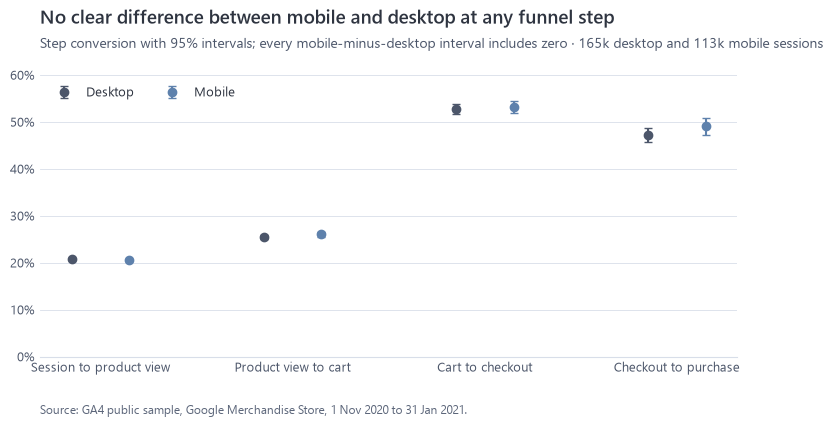

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.4))
labels = [s[0] for s in steps[:4]]
for i, (device, color, offset) in enumerate([("desktop", PAL["ink_2"], -0.15), ("mobile", PAL["primary"], 0.15)]):
    d = device_steps[(device_steps.device == device) & device_steps.step.isin(labels)].set_index("step").loc[labels]
    x = np.arange(len(labels)) + offset
    ax.errorbar(x, d.rate * 100, yerr=[(d.rate - d.low) * 100, (d.high - d.rate) * 100], fmt="o", color=color,
                capsize=3, label=device.capitalize())
ax.set_xticks(np.arange(len(labels)), labels); ax.set_ylim(0, 60)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0f}%")
ax.legend(loc="upper left", ncols=2)
finish(fig, ax, "No clear difference between mobile and desktop at any funnel step",
       f"Step conversion with 95% intervals; every mobile-minus-desktop interval includes zero · "
       f"{dev.loc['desktop', 'sessions'] / 1000:.0f}k desktop and {dev.loc['mobile', 'sessions'] / 1000:.0f}k mobile sessions",
       f"{IMG}/device_funnel.png")
plt.show()

## 3. Landing pages

The landing page is the first page of a session. Paths are lower-cased and stripped of the domain and query string, so the store's three home-page addresses count as one. About 7% of sessions have no landing page recorded.

In [7]:
landing = sql("""
    with s as (
        select lower(rtrim(regexp_replace(regexp_replace(landing_page, '^https?://[^/]+', ''), '[?#].*$', ''), '/')) as path,
               session_channel_group as channel, reached_purchase, revenue_usd
        from marts.fct_sessions where landing_page is not null)
    select case when path = '' then '/ (home)' else path end as page,
           count(*) as sessions, count_if(reached_purchase) as purchases, sum(revenue_usd) as revenue,
           mode(channel) as main_channel
    from s group by 1""")
landing["conversion"] = landing.purchases / landing.sessions
landing["revenue_per_session"] = landing.revenue / landing.sessions
landing[["low", "high"]] = landing.apply(lambda r: pd.Series(wilson(r.purchases, r.sessions)), axis=1)
landing["traffic_share"] = landing.sessions / landing.sessions.sum()
site_cvr = landing.purchases.sum() / landing.sessions.sum()
big = landing[landing.sessions >= 1000].sort_values("sessions", ascending=False).reset_index(drop=True)
print(f"{len(landing):,} landing pages; {len(big)} with 1,000+ sessions cover {big.sessions.sum() / landing.sessions.sum():.0%} "
      f"of sessions; site conversion {site_cvr:.2%}")
big[["page", "sessions", "traffic_share", "purchases", "conversion", "low", "high", "revenue_per_session", "main_channel"]]

950 landing pages; 23 with 1,000+ sessions cover 90% of sessions; site conversion 1.45%


,page,sessions,traffic_share,purchases,conversion,low,high,revenue_per_session,main_channel
0,/ (home),153026,0.4586,"2,719.0000",0.0178,0.0171,0.0184,1.2099,Direct
1,/google+redesign/apparel,39234,0.1176,136.0000,0.0035,0.0029,0.0041,0.2665,Direct
2,/google+redesign/shop+by+brand/youtube,24598,0.0737,53.0000,0.0022,0.0016,0.0028,0.0594,Organic Search
3,/google+redesign/apparel/google+dino+game+tee,18653,0.0559,4.0000,0.0002,0.0001,0.0006,0.0175,Organic Search
4,/store.html,14024,0.0420,164.0000,0.0117,0.0100,0.0136,1.0037,Direct
5,/google+redesign/apparel/mens/mens+t+shirts,7039,0.0211,47.0000,0.0067,0.0050,0.0089,0.2681,Organic Search
6,/google+redesign/lifestyle/drinkware,5087,0.0152,44.0000,0.0086,0.0064,0.0116,0.7157,Direct
7,/signin.html,4298,0.0129,126.0000,0.0293,0.0247,0.0348,2.0165,Internal Referral
8,/google+redesign/apparel/mens,4232,0.0127,149.0000,0.0352,0.0301,0.0412,3.4728,Internal Referral
9,/basket.html,3764,0.0113,380.0000,0.1010,0.0917,0.1110,8.1214,Internal Referral


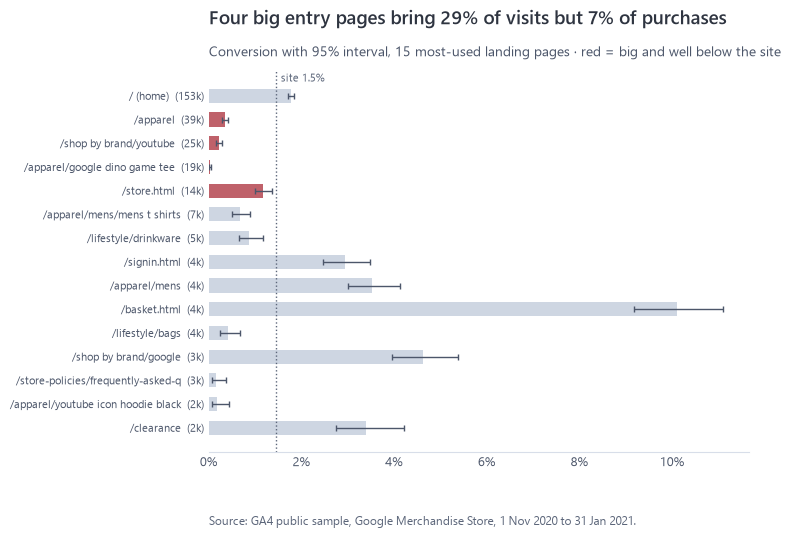

In [8]:
weak_pages = big[(big.high < site_cvr) & (big.traffic_share > 0.03)]
weak_visits = weak_pages.traffic_share.sum()
weak_buys = weak_pages.purchases.sum() / landing.purchases.sum()
top = big.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5.6))
y = np.arange(len(top))
weak = (top.high < site_cvr) & (top.traffic_share > 0.03)
colors = [PAL["accent"] if w else PAL["context"] for w in weak]
ax.barh(y, top.conversion * 100, color=colors, height=0.6)
ax.errorbar(top.conversion * 100, y, xerr=[(top.conversion - top.low) * 100, (top.high - top.conversion) * 100],
            fmt="none", ecolor=PAL["ink_2"], capsize=2, lw=1)
ax.axvline(site_cvr * 100, color=PAL["muted"], ls=":", lw=1)
ax.text(site_cvr * 100 + 0.1, len(top) - 0.4, f"site {site_cvr:.1%}", fontsize=8, color=PAL["muted"])
names = [f"{p.replace('/google+redesign', '').replace('+', ' ')[:34]}  ({s / 1000:.0f}k)" for p, s in zip(top.page, top.sessions)]
ax.set_yticks(y, names, fontsize=8); ax.grid(False)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0f}%")
count_word = ["No", "One", "Two", "Three", "Four", "Five", "Six"][len(weak_pages)]
finish(fig, ax, f"{count_word} big entry pages bring {weak_visits:.0%} of visits but {weak_buys:.0%} of purchases",
       "Conversion with 95% interval, 15 most-used landing pages · red = big and well below the site",
       f"{IMG}/landing_pages.png", left=0.3, top=0.84)
plt.show()

In [9]:
print(f"weak big entry pages: {len(weak_pages)}, {weak_visits:.0%} of sessions, {weak_buys:.1%} of purchases")
weak_pages[["page", "sessions", "conversion", "main_channel"]]

weak big entry pages: 4, 29% of sessions, 7.4% of purchases


,page,sessions,conversion,main_channel
1,/google+redesign/apparel,39234,0.0035,Direct
2,/google+redesign/shop+by+brand/youtube,24598,0.0022,Organic Search
3,/google+redesign/apparel/google+dino+game+tee,18653,0.0002,Organic Search
4,/store.html,14024,0.0117,Direct


In [10]:
channel_mix = sql("""
    select lower(rtrim(regexp_replace(regexp_replace(landing_page, '^https?://[^/]+', ''), '[?#].*$', ''), '/')) as path,
           session_channel_group as channel, count(*) as sessions
    from marts.fct_sessions where landing_page is not null group by 1, 2""")
channel_mix["share"] = channel_mix.sessions / channel_mix.groupby("path").sessions.transform("sum")
channel_mix[channel_mix.path.isin(weak_pages.page)].sort_values(["path", "share"], ascending=[True, False]).groupby("path").head(3)

,path,channel,sessions,share
2369,/google+redesign/apparel,Direct,24633,0.6278
2548,/google+redesign/apparel,Organic Search,10510,0.2679
1852,/google+redesign/apparel,Internal Referral,2116,0.0539
1346,/google+redesign/apparel/google+dino+game+tee,Organic Search,7952,0.4263
1548,/google+redesign/apparel/google+dino+game+tee,Direct,4151,0.2225
2059,/google+redesign/apparel/google+dino+game+tee,Obfuscated,3014,0.1616
2514,/google+redesign/shop+by+brand/youtube,Organic Search,9150,0.3720
2335,/google+redesign/shop+by+brand/youtube,Direct,7089,0.2882
364,/google+redesign/shop+by+brand/youtube,Obfuscated,3054,0.1242
1663,/store.html,Direct,9161,0.6532


## 4. Order values

Orders from 26 to 31 January are left out: their values weren't recorded. Channel is the corrected last-click channel.

In [11]:
orders = sql("""
    with products as (select order_id, count(distinct item_name) as products from marts.fct_order_items group by 1)
    select o.order_id, o.purchase_revenue_usd as value, coalesce(p.products, 0) as products,
           a.channel, row_number() over (partition by o.user_pseudo_id order by o.order_ts) as nth_order
    from marts.fct_orders o
    join marts.dim_date d on d.date = o.order_date
    left join products p on p.order_id = o.order_id
    left join marts.fct_attribution_credits a on a.order_id = o.order_id and a.model = 'last_click' and a.credit = 1
    where d.is_revenue_tracking_ok""")
q = orders.value.quantile([0.25, 0.5, 0.75, 0.9, 0.99])
top_cut = orders.value.sort_values(ascending=False)
top_share = {pct: top_cut.head(int(len(orders) * pct)).sum() / orders.value.sum() for pct in (0.01, 0.05, 0.10)}
print(f"{len(orders):,} orders | mean ${orders.value.mean():.0f} | median ${q[0.5]:.0f} | "
      f"p25 ${q[0.25]:.0f} p75 ${q[0.75]:.0f} p90 ${q[0.9]:.0f} p99 ${q[0.99]:.0f}")
print({f"top {int(k * 100)}% of orders": f"{v:.0%} of revenue" for k, v in top_share.items()})

5,028 orders | mean $67 | median $46 | p25 $24 p75 $83 p90 $138 p99 $369
{'top 1% of orders': '9% of revenue', 'top 5% of orders': '24% of revenue', 'top 10% of orders': '35% of revenue'}


In [12]:
segments = pd.concat([
    orders.assign(group=np.where(orders.products > 1, "Several products", "One product")),
    orders.assign(group=np.where(orders.nth_order > 1, "Repeat order", "First order")),
])
segments.groupby("group").value.agg(orders="size", mean="mean", median="median").round(0)

,orders,mean,median
group,,,
First order,4184,68.0000,48.0000
One product,1945,37.0000,25.0000
Repeat order,844,59.0000,42.0000
Several products,3083,86.0000,63.0000


In [13]:
by_channel = orders.groupby("channel").value.agg(orders="size", mean="mean", median="median")
by_channel[by_channel.orders >= 100].sort_values("orders", ascending=False).round(0)

,orders,mean,median
channel,,,
Organic Search,2064,65.0000,45.0000
Referral,1243,69.0000,48.0000
Unknown,664,67.0000,44.0000
Direct,539,74.0000,55.0000
Obfuscated,427,60.0000,45.0000


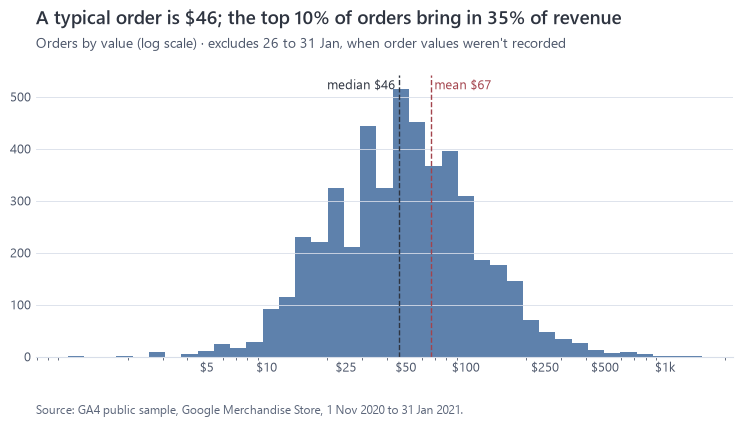

In [14]:
fig, ax = plt.subplots(figsize=(9, 4.4))
bins = np.logspace(np.log10(max(orders.value.min(), 1)), np.log10(orders.value.max()), 40)
ax.hist(orders.value, bins=bins, color=PAL["primary"])
ax.set_xscale("log")
ax.set_xticks([5, 10, 25, 50, 100, 250, 500, 1000], ["$5", "$10", "$25", "$50", "$100", "$250", "$500", "$1k"])
for value, label, color, ha, nudge in [(q[0.5], "median", PAL["ink"], "right", 0.96),
                                       (orders.value.mean(), "mean", PAL["accent_text"], "left", 1.04)]:
    ax.axvline(value, color=color, ls="--", lw=1)
    ax.text(value * nudge, ax.get_ylim()[1] * 0.95, f"{label} ${value:.0f}", fontsize=9, color=color, ha=ha)
finish(fig, ax, f"A typical order is ${q[0.5]:.0f}; the top 10% of orders bring in {top_share[0.10]:.0%} of revenue",
       "Orders by value (log scale) · excludes 26 to 31 Jan, when order values weren't recorded",
       f"{IMG}/order_values.png")
plt.show()

## 5. Products and baskets

**A data check first.** In this sample, product-view and add-to-cart events each list about 11 products, not the one product viewed or added, so they can't say which product someone looked at. A per-product view-to-cart funnel would be wrong, so products are judged on purchases only.

In [15]:
sql("""
    select event_name, count(distinct event_key) as events,
           round(count(*) * 1.0 / count(distinct event_key), 1) as products_per_event
    from staging.stg_ga4__event_items where event_name in ('view_item', 'add_to_cart', 'purchase') group by 1""")

,event_name,events,products_per_event
0,view_item,241876,11.4000
1,add_to_cart,58543,11.4000
2,purchase,5690,2.8000


In [16]:
items = sql("""
    select i.order_id, i.item_name as product, coalesce(nullif(i.item_category, ''), '(not set)') as category,
           i.quantity, i.item_revenue_usd as revenue
    from marts.fct_order_items i""")
cat = items.groupby("category").agg(orders=("order_id", "nunique"), units=("quantity", "sum"),
                                    revenue=("revenue", "sum")).sort_values("revenue", ascending=False)
cat["revenue_share"] = cat.revenue / cat.revenue.sum()
cat.head(10)

,orders,units,revenue,revenue_share
category,,,,
Apparel,2774,5023,"158,648.0000",0.4690
New,998,2033,"24,727.0000",0.0731
Bags,568,1015,"22,718.0000",0.0672
Campus Collection,781,1980,"18,316.0000",0.0541
Accessories,830,1884,"16,688.0000",0.0493
Shop by Brand,723,1156,"16,282.0000",0.0481
Uncategorized Items,450,761,"16,248.0000",0.0480
Drinkware,607,1029,"14,695.0000",0.0434
Lifestyle,500,753,"12,653.0000",0.0374


In [17]:
prod = items.groupby("product").agg(orders=("order_id", "nunique"), units=("quantity", "sum"),
                                    revenue=("revenue", "sum")).sort_values("revenue", ascending=False)
prod["revenue_share"] = prod.revenue / prod.revenue.sum()
prod["cumulative"] = prod.revenue_share.cumsum()
n_half = int((prod.cumulative < 0.5).sum()) + 1
print(f"{len(prod)} products sold; the top {n_half} ({n_half / len(prod):.0%}) make half of item revenue")
prod.head(10)

396 products sold; the top 36 (9%) make half of item revenue


,orders,units,revenue,revenue_share,cumulative
product,,,,,
Google Zip Hoodie F/C,230,260,"13,152.0000",0.0389,0.0389
Google Crewneck Sweatshirt Navy,196,217,"9,878.0000",0.0292,0.0681
Super G Unisex Joggers,256,294,"9,103.0000",0.0269,0.0950
Google Badge Heavyweight Pullover Black,153,179,"8,628.0000",0.0255,0.1205
Google Men's Tech Fleece Grey,95,115,"8,508.0000",0.0251,0.1456
Google Crewneck Sweatshirt Green,157,166,"7,579.0000",0.0224,0.1680
Google Sherpa Zip Hoodie Charcoal,95,108,"6,012.0000",0.0178,0.1858
Google Men's Puff Jacket Black,56,59,"5,635.0000",0.0167,0.2025
Google Men's Tech Fleece Vest Charcoal,64,81,"5,360.0000",0.0158,0.2183


In [18]:
multi = items.groupby("order_id")["product"].nunique()
print(f"{(multi > 1).mean():.0%} of orders contain more than one product (median {multi.median():.0f})")
pairs = basket_pairs(items[["order_id", "product"]], min_orders=30)
pairs.head(12)

59% of orders contain more than one product (median 2)


,product_a,product_b,orders_together,support,confidence_a_to_b,confidence_b_to_a,lift
0,Google Light Pen Green,Google Light Pen Red,40,0.0076,0.6557,0.5797,50.2352
1,Google Light Pen Blue,Google Light Pen Red,39,0.0074,0.4699,0.5652,35.9969
2,Google Light Pen Blue,Google Light Pen Green,35,0.0066,0.4217,0.5738,36.5416
3,Android Large Removable Sticker Sheet,Android SM S/F18 Sticker Sheet,30,0.0057,0.5882,0.2804,29.0599
4,Google Crew Combed Cotton Sock,Google Crew Socks,30,0.0057,0.3261,0.2128,12.2248


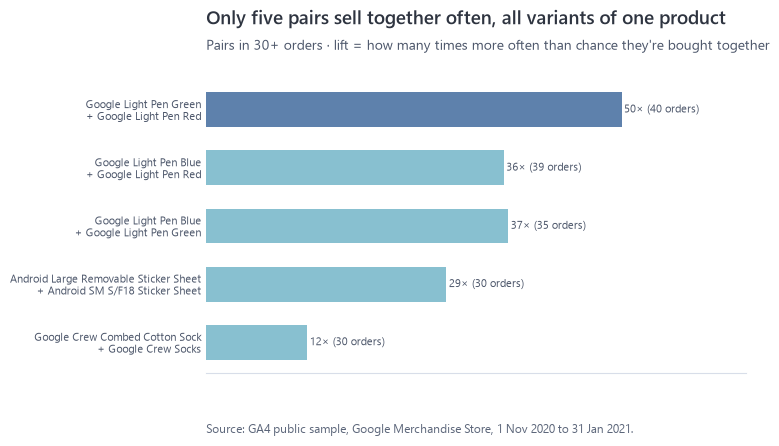

In [19]:
fig, ax = plt.subplots(figsize=(9, 4.6))
show = pairs.head(10).iloc[::-1]
y = np.arange(len(show))
ax.barh(y, show.lift, color=[PAL["primary"] if v == show.lift.max() else PAL["secondary"] for v in show.lift], height=0.6)
for yi, (lift, n) in enumerate(zip(show.lift, show.orders_together)):
    ax.text(lift + 0.3, yi, f"{lift:.0f}× ({n} orders)", va="center", fontsize=8, color=PAL["ink_2"])
ax.set_yticks(y, [f"{a}\n+ {b}" for a, b in zip(show.product_a, show.product_b)], fontsize=8)
ax.set_xticks([]); ax.grid(False); ax.set_xlim(0, show.lift.max() * 1.3)
n_word = ["no", "one", "two", "three", "four", "five", "six", "seven", "eight", "nine", "ten"][min(len(pairs), 10)]
finish(fig, ax, f"Only {n_word} pairs sell together often, all variants of one product",
       "Pairs in 30+ orders · lift = how many times more often than chance they're bought together",
       f"{IMG}/basket_pairs.png", left=0.3)
plt.show()

## 6. Repeat purchase by first-purchase month

Share of customers who bought again within 7, 14 and 30 days of their first buying day. A customer only counts for a window if the data runs at least that many days past their first purchase (it ends on 31 January), so January's customers have little to show.

In [20]:
cust = sql("select first_order_date, cohort_month, days_to_repeat, acquisition_channel from marts.dim_customers")
end = pd.Timestamp("2021-01-31")
rows = []
for window in (7, 14, 30):
    eligible = cust[pd.to_datetime(cust.first_order_date) + pd.Timedelta(days=window) <= end]
    for month, g in eligible.groupby("cohort_month"):
        k = int((g.days_to_repeat <= window).sum())
        if len(g) >= 100:  # too few eligible customers otherwise
            rows.append((pd.Timestamp(month).strftime("%b %Y"), window, len(g), k / len(g), *wilson(k, len(g))))
grid = pd.DataFrame(rows, columns=["cohort", "window", "eligible", "repeat_rate", "low", "high"])
grid.pivot(index="cohort", columns="window", values=["repeat_rate", "eligible"])

repeat_rate                 eligible                      
window            7      14     30         7          14         30
cohort                                                             
Dec 2020      0.0358 0.0465 0.0567 1,870.0000 1,870.0000 1,870.0000
Jan 2021      0.0260 0.0365    NaN   731.0000   384.0000        NaN
Nov 2020      0.0339 0.0522 0.0881 1,532.0000 1,532.0000 1,532.0000

In [21]:
by_ch = cust.groupby("acquisition_channel").agg(customers=("days_to_repeat", "size"),
                                                repeaters=("days_to_repeat", lambda s: s.notna().sum()))
by_ch["repeat_rate"] = by_ch.repeaters / by_ch.customers
by_ch[["low", "high"]] = by_ch.apply(lambda r: pd.Series(wilson(r.repeaters, r.customers)), axis=1)
by_ch[by_ch.customers >= 100].sort_values("customers", ascending=False)

,customers,repeaters,repeat_rate,low,high
acquisition_channel,,,,,
Organic Search,1909,132,0.0691,0.0586,0.0814
Referral,1048,89,0.0849,0.0695,0.1034
Internal Referral,634,55,0.0868,0.0673,0.1112
Direct,458,34,0.0742,0.0536,0.1019
Obfuscated,267,13,0.0487,0.0287,0.0815


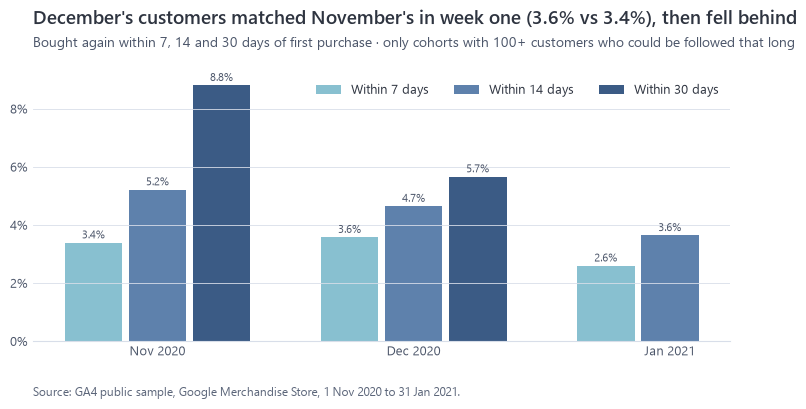

In [22]:
fig, ax = plt.subplots(figsize=(9, 4.2))
cohorts = ["Nov 2020", "Dec 2020", "Jan 2021"]
width = 0.25
for i, window in enumerate((7, 14, 30)):
    g = grid[grid.window == window].set_index("cohort").reindex(cohorts)
    x = np.arange(len(cohorts)) + (i - 1) * width
    color = [PAL["secondary"], PAL["primary"], PAL["primary_strong"]][i]
    ax.bar(x, g.repeat_rate * 100, width * 0.9, color=color, label=f"Within {window} days")
    for xi, v, n in zip(x, g.repeat_rate * 100, g.eligible):
        if not np.isnan(v):
            ax.text(xi, v + 0.15, f"{v:.1f}%", ha="center", fontsize=8, color=PAL["ink_2"])
ax.set_xticks(np.arange(len(cohorts)), cohorts)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0f}%")
ax.legend(loc="upper right", ncols=3)
r = grid.set_index(["cohort", "window"]).repeat_rate
finish(fig, ax, f"December's customers matched November's in week one ({r['Dec 2020', 7]:.1%} vs {r['Nov 2020', 7]:.1%}), "
       f"then fell behind",
       "Bought again within 7, 14 and 30 days of first purchase · only cohorts with 100+ customers who could be followed that long",
       f"{IMG}/repeat_grid.png")
plt.show()

## 7. Two summary views for the report

**What happens to 100 product viewers** (days with working cart tracking), and **what drove January's revenue drop**: revenue per day = sessions per day × conversion rate × order value, so the log of the change splits exactly into those three parts. Days with recorded order values only.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


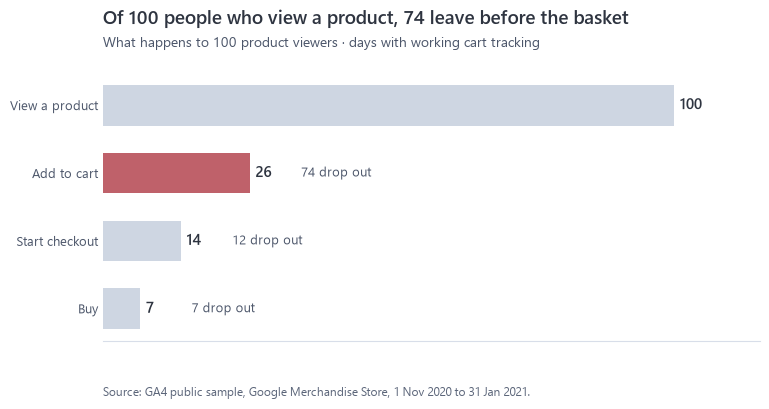

In [23]:
_, v, c, k, p = (dev.sum()[["sessions", "viewed", "carted", "checkout", "purchased"]])
flow = [100, 100 * c / v, 100 * k / v, 100 * p / v]
labels = ["View a product", "Add to cart", "Start checkout", "Buy"]
fig, ax = plt.subplots(figsize=(9, 4.2))
y = np.arange(4)[::-1]
ax.barh(y, flow, color=[PAL["context"], PAL["accent"], PAL["context"], PAL["context"]], height=0.6)
for yi, val, prev in zip(y, flow, [None] + flow[:-1]):
    ax.text(val + 1, yi, f"{val:.0f}", va="center", fontsize=11, color=PAL["ink"], weight="semibold")
    if prev is not None:
        ax.text(val + 9, yi, f"{prev - val:.0f} drop out", va="center", fontsize=9, color=PAL["ink_2"])
ax.set_yticks(y, labels); ax.set_xticks([]); ax.grid(False); ax.set_xlim(0, 115)
finish(fig, ax, f"Of 100 people who view a product, {100 - flow[1]:.0f} leave before the basket",
       "What happens to 100 product viewers · days with working cart tracking", f"{IMG}/viewer_flow.png", left=0.17)
plt.show()

In [24]:
jan = sql("""
    select d.month_label as month, count(distinct d.date) as n_days, count(*) as sessions,
           sum(s.orders) as orders, sum(s.revenue_usd) as revenue
    from marts.fct_sessions s join marts.dim_date d on d.date = s.session_date
    where d.is_revenue_tracking_ok and d.month_label in ('Dec 2020', 'Jan 2021') group by 1""").set_index("month")
dec_, jan_ = jan.loc["Dec 2020"], jan.loc["Jan 2021"]
parts = pd.Series({
    "Traffic (sessions per day)": (jan_.sessions / jan_.n_days) / (dec_.sessions / dec_.n_days),
    "Conversion rate": (jan_.orders / jan_.sessions) / (dec_.orders / dec_.sessions),
    "Order value": (jan_.revenue / jan_.orders) / (dec_.revenue / dec_.orders),
})
total = (jan_.revenue / jan_.n_days) / (dec_.revenue / dec_.n_days)
share = np.log(parts) / np.log(total)
pd.DataFrame({"change": parts - 1, "share_of_drop": share}).round(3)

,change,share_of_drop
Traffic (sessions per day),-0.1080,0.1340
Conversion rate,-0.4710,0.7460
Order value,-0.0970,0.1200


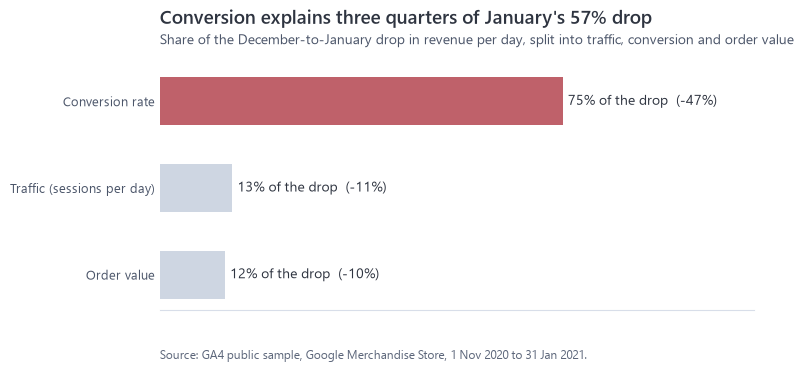

In [25]:
fig, ax = plt.subplots(figsize=(9, 3.8))
order = share.sort_values().index
y = np.arange(len(order))
ax.barh(y, share[order] * 100, color=[PAL["accent"] if i == "Conversion rate" else PAL["context"] for i in order], height=0.55)
for yi, name in zip(y, order):
    ax.text(share[name] * 100 + 1, yi, f"{share[name]:.0%} of the drop  ({parts[name] - 1:+.0%})", va="center",
            fontsize=10, color=PAL["ink"])
ax.set_yticks(y, order); ax.set_xticks([]); ax.grid(False); ax.set_xlim(0, 110)
finish(fig, ax, f"Conversion explains three quarters of January's {1 - total:.0%} drop",
       "Share of the December-to-January drop in revenue per day, split into traffic, conversion and order value",
       f"{IMG}/january_decomposition.png", left=0.24)
plt.show()

## 8. Sizing the recommended tests

Units each arm needs (two-sided test, 95% confidence, 80% power) and how long that takes at January's daily volumes, the post-holiday level the tests would run at. These numbers feed the test plan in the report.

In [26]:
jan_vol = sql("""
    select count(distinct d.date) as n_days, count_if(reached_view_item) as viewers, count_if(reached_begin_checkout) as checkouts
    from marts.fct_sessions s join marts.dim_date d on d.date = s.session_date
    where d.is_cart_tracking_ok and d.month_label = 'Jan 2021'""").iloc[0]
new_customers_per_day = len(cust) / 92
rates = {"view to cart": c / v, "checkout to purchase": p / k}
plan = []
for test, base, per_day in [("Product page (view to cart)", rates["view to cart"], jan_vol.viewers / jan_vol.n_days),
                            ("Checkout (checkout to purchase)", rates["checkout to purchase"], jan_vol.checkouts / jan_vol.n_days)]:
    for lift in (0.05, 0.10):
        n = sample_size_per_arm(base, lift)
        plan.append((test, f"{base:.1%}", f"+{lift:.0%}", n, 2 * n / per_day))
for base in (0.057, 0.088):  # 30-day repeat: December and November cohorts
    n = sample_size_per_arm(base, 0.30)
    plan.append(("Second-purchase offer (30-day repeat)", f"{base:.1%}", "+30%", n, 2 * n / new_customers_per_day))
pd.DataFrame(plan, columns=["test", "baseline", "lift to detect", "per arm", "days needed"]).round(0)

,test,baseline,lift to detect,per arm,days needed
0,Product page (view to cart),25.7%,+5%,18445,49.0000
1,Product page (view to cart),25.7%,+10%,4682,13.0000
2,Checkout (checkout to purchase),48.0%,+5%,6820,196.0000
3,Checkout (checkout to purchase),48.0%,+10%,1705,49.0000
4,Second-purchase offer (30-day repeat),5.7%,+30%,3288,137.0000
5,Second-purchase offer (30-day repeat),8.8%,+30%,2048,85.0000
